In [1]:
import scipy as sp
import warnings
warnings.filterwarnings("ignore")
try: # Account for different module conventions in different versions of scipy
    from scipy.misc import derivative
except ImportError:
    from scipy.differentiate import derivative
from scipy.special import jv, hankel2, hankel1, yv, jvp, yvp, spherical_jn, spherical_yn, factorial2
import numpy as np
import matplotlib.pyplot as plt
from numpy import sqrt, linspace, zeros, ones, pi, exp, conj, argmin, unravel_index, log, tan, einsum, log10
import torch
from utils import hl2, hl2prime, hl1, hl1prime, e_r_cpa, h_r_cpa, e_r_cpa_numerator, h_r_cpa_numerator, graphene_conductivity
from utils import hbar, c, alpha # Plank's constant in eV*s, speed of light in nanometers per second, fine structure constant
tau = 6.4*1e-13 # scattering time in seconds

### In this notebook, we compare the local approximation to the CPA conductivity with two different nonlocal approximations. The first nonlocal approximation does not fully take into account dissipation in the generalized Ohm's law (e.g. $\frac{1}{\omega(\omega+i/\tau)}\nabla(\nabla\cdot \mathbf{J})\rightarrow \frac{1}{\omega^2}\nabla(\nabla\cdot \mathbf{J})$. See the supplement of our paper for more info.

In [68]:
M = 10000
epsilon = 2.1
x = linspace(0.06, 0.2, M) # Free space kR
m = sqrt(epsilon)
y = x * m # epsilonkR in the cylinder

ls = np.array([1, 2, 3])
sigma_real_l = np.zeros((len(ls), len(x)))
sigma_imaginary_l = np.zeros((len(ls), len(x)))

sigma_real_nonlocal1_l = np.zeros((len(ls), len(x)))
sigma_imaginary_nonlocal1_l = np.zeros((len(ls), len(x)))

sigma_real_nonlocal2_l = np.zeros((len(ls), len(x)))
sigma_imaginary_nonlocal2_l = np.zeros((len(ls), len(x)))

beta_over_c = 0.01

for (l_idx, l) in enumerate(ls):
    print("Angular momentum (l): ", l)
    j_ly = spherical_jn(l, y)
    j_lx = spherical_jn(l, x)
    y_lx = spherical_yn(l, x)
    
    yjl_prime = spherical_jn(l, y) + y*spherical_jn(l, y, derivative=True)
    xjl_prime = spherical_jn(l, x) + x*spherical_jn(l, x, derivative=True)
    xyl_prime = spherical_yn(l, x) + x*spherical_yn(l, x, derivative=True)
    
    prefac = x/(yjl_prime*(xjl_prime**2+xyl_prime **2))
    mat = np.array([[xyl_prime, xjl_prime], [-xjl_prime , xyl_prime]])
    vec = np.array([j_lx*yjl_prime-epsilon*xjl_prime*j_ly, epsilon*j_ly*xyl_prime-y_lx*yjl_prime])

    sigmas = prefac * einsum("ijk, jk -> ik", mat, vec)
    sigma_real = sigmas[0, :]
    sigma_imaginary = sigmas[1, :]
    
    sigma_real_l[l_idx, :] = sigma_real
    sigma_imaginary_l[l_idx, :] = sigma_imaginary

    sigma_real_nonlocal1_l[l_idx, :] = sigma_real * (1-(beta_over_c**2)*l*(l+1)/x**2)
    sigma_imaginary_nonlocal1_l[l_idx, :] = sigma_imaginary * (1-(beta_over_c**2)*l*(l+1)/x**2)

    sigma_nonlocal2 = (sigma_real**2+sigma_imaginary**2)/(sigma_real - 1j*sigma_imaginary/(1-(beta_over_c**2)*l*(l+1)/x**2))
   
    sigma_real_nonlocal2_l[l_idx, :] =  sigma_nonlocal2.real
    sigma_imaginary_nonlocal2_l[l_idx, :] =  sigma_nonlocal2.imag

Angular momentum (l):  1
Angular momentum (l):  2
Angular momentum (l):  3


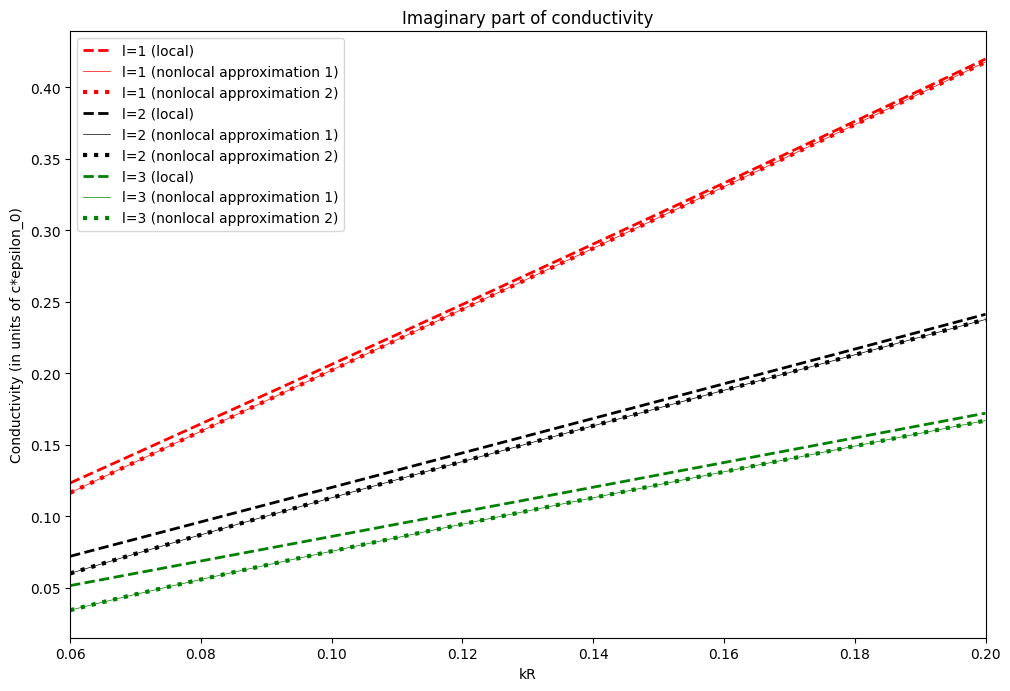

In [81]:
cm = 1/2.54
fig, ax1 = plt.subplots(1, 1, figsize=(30*cm, 20*cm))

l_colors = ["red", "black", "green"]
for (l_idx, l) in enumerate(ls):
    color = l_colors[l_idx]
    sigma_imaginary = sigma_imaginary_l[l_idx]
    sigma_real = sigma_real_l[l_idx]

    sigma_imaginary_nonlocal1 = sigma_imaginary_nonlocal1_l[l_idx]
    sigma_real_nonlocal1 = sigma_real_nonlocal1_l[l_idx]

    sigma_imaginary_nonlocal2 = sigma_imaginary_nonlocal2_l[l_idx]
    sigma_real_nonlocal2 = sigma_real_nonlocal2_l[l_idx]

    ax1.plot(x, sigma_imaginary, label=f"l={l} (local)", color=color, linestyle="dashed", linewidth=2)
    ax1.plot(x, sigma_imaginary_nonlocal1, label=f"l={l} (nonlocal approximation 1)", color=color, linestyle="solid", linewidth=0.5)
    ax1.plot(x, sigma_imaginary_nonlocal2, label=f"l={l} (nonlocal approximation 2)", color=color, linestyle="dotted", linewidth=3)

    ax1.set_xlim(0.06, 0.2)
    ax1.set_title("Imaginary part of conductivity")
    ax1.set_ylabel("Conductivity (in units of c*epsilon_0)")
    ax1.set_xlabel("kR");
    ax1.legend()